In [13]:
import cv2
import numpy as np
import os
import matplotlib.pyplot as plt
from plyfile import PlyData, PlyElement
from glob import glob
from tqdm import tqdm

In [14]:
left_path = sorted(glob("graphs_stereo/*_left.png"))[:24]
right_path = sorted(glob("graphs_stereo/*_right.png"))[:24]
print(f"{len(left_path)} pairs of images found")

24 pairs of images found


In [15]:
chessboard_size = (11, 8)
square_size = 14.5

criteria = (cv2.TERM_CRITERIA_EPS + cv2.TERM_CRITERIA_MAX_ITER, 30, 0.001)

obj_points = []
img_points_left = []
img_points_right = []

objp = np.zeros((chessboard_size[0] * chessboard_size[1], 3), np.float32)
objp[:, :2] = np.mgrid[0:chessboard_size[0], 0:chessboard_size[1]].T.reshape(-1, 2)
objp[:, :2] *= square_size

# 遍历所有图像对检测角点
failed_pairs = []  # 记录检测失败的图像对
for i in tqdm(range(len(left_path)), desc="checking"):
    img_l = cv2.imread(left_path[i])
    img_r = cv2.imread(right_path[i])
    gray_l = cv2.cvtColor(img_l, cv2.COLOR_BGR2GRAY)
    gray_r = cv2.cvtColor(img_r, cv2.COLOR_BGR2GRAY)
    
    # 检测左图角点
    ret_l, corners_l = cv2.findChessboardCorners(gray_l, chessboard_size, None)
    # 检测右图角点
    ret_r, corners_r = cv2.findChessboardCorners(gray_r, chessboard_size, None)
    
    # 若左右图均检测到角点，则优化并保存
    if ret_l and ret_r:
        # 亚像素级角点优化（提高精度）
        corners_l_refined = cv2.cornerSubPix(gray_l, corners_l, (11, 11), (-1, -1), criteria)
        corners_r_refined = cv2.cornerSubPix(gray_r, corners_r, (11, 11), (-1, -1), criteria)
        
        obj_points.append(objp)
        img_points_left.append(corners_l_refined)
        img_points_right.append(corners_r_refined)
    else:
        failed_pairs.append(i)
        print(f"\nthe {i}-th (img_{i:02d}) failed")

# 统计有效图像对
print(f"\nsucceed: {len(obj_points)}, failed: {len(failed_pairs)}")

checking: 100%|██████████| 24/24 [00:08<00:00,  2.78it/s]


succeed: 24, failed: 0


In [16]:
# for idx in range(24):
#     img_l = cv2.imread(left_path[idx])
#     img_r = cv2.imread(right_path[idx])

#     cv2.drawChessboardCorners(img_l, chessboard_size, img_points_left[idx], True)
#     cv2.drawChessboardCorners(img_r, chessboard_size, img_points_right[idx], True)
    
#     plt.figure(figsize=(12, 6))
#     plt.subplot(121)
#     plt.imshow(cv2.cvtColor(img_l, cv2.COLOR_BGR2RGB))
#     plt.title(f"left {idx}")
#     plt.subplot(122)
#     plt.imshow(cv2.cvtColor(img_r, cv2.COLOR_BGR2RGB))
#     plt.title(f"right {idx}")
#     plt.show()

In [17]:
img_shape = gray_l.shape[::-1]

In [18]:
ret_l, K1, D1, rvecs_l, tvecs_l = cv2.calibrateCamera(obj_points, img_points_left, img_shape, None, None)

img_points_right = img_points_right[:24]
ret_r, K2, D2, rvecs_r, tvecs_r = cv2.calibrateCamera(obj_points, img_points_right, img_shape, None, None)

print("left | inner parameters K1: \n", K1)
print("\nleft | distortion coefficients D1: \n", D1)
print(f"\nleft | reprojection error: {ret_l:.4f} pixels")
print("\nright | inner parameters K2: \n", K2)
print("\nright | distortion coefficients D2: \n", D2)
print(f"\nright | reprojection error: {ret_r:.4f} pixels")

left | inner parameters K1: 
 [[3.70105192e+03 0.00000000e+00 1.20634463e+03]
 [0.00000000e+00 3.70255775e+03 9.97331796e+02]
 [0.00000000e+00 0.00000000e+00 1.00000000e+00]]

left | distortion coefficients D1: 
 [[-5.39906657e-01 -2.20093148e-01  3.03760632e-04  3.21675416e-03
   3.59199208e+00]]

left | reprojection error: 0.4707 pixels

right | inner parameters K2: 
 [[3.66664027e+03 0.00000000e+00 1.23451509e+03]
 [0.00000000e+00 3.66841643e+03 9.73886797e+02]
 [0.00000000e+00 0.00000000e+00 1.00000000e+00]]

right | distortion coefficients D2: 
 [[-5.61094367e-01  1.68985314e-01  1.61088974e-03  1.34425247e-03
   2.80867687e+00]]

right | reprojection error: 0.4119 pixels


In [35]:
ret, _, _, _, _, R, T, E, F = cv2.stereoCalibrate(
    obj_points,
    img_points_left,
    img_points_right,
    K1, D1, K2, D2,
    img_shape,
    criteria=criteria,
    flags=cv2.CALIB_FIX_INTRINSIC
)

print(f"mean reprojection error: {ret:.4f} pixels")
print("\nRotation Matrix R: \n", R)
print("\nTranslation Vector T: \n", T)

mean reprojection error: 0.7413 pixels

Rotation Matrix R: 
 [[ 0.99577337  0.00966348  0.09133457]
 [-0.00889361  0.99992144 -0.00883238]
 [-0.09141274  0.00798275  0.99578109]]

Translation Vector T: 
 [[-7.21281741e+01]
 [-6.49813306e-02]
 [-4.99233761e+00]]


In [36]:
# 立体校正：计算校正所需的旋转矩阵、投影矩阵和视差到深度的映射矩阵Q
R1, R2, P1, P2, Q, validPixROI1, validPixROI2 = cv2.stereoRectify(
    K1, D1,  # 左相机内参和畸变系数
    K2, D2,  # 右相机内参和畸变系数
    img_shape,  # 图像尺寸 (宽, 高)
    R, T,  # 立体标定得到的旋转矩阵和平移向量
    flags=cv2.CALIB_ZERO_DISPARITY,  # 视差起点为0
    alpha=0  # 输出图像不裁剪（保留所有像素）
)

In [38]:
print(" Q: \n", Q)

 Q: 
 [[ 1.00000000e+00  0.00000000e+00  0.00000000e+00 -7.99645691e+02]
 [ 0.00000000e+00  1.00000000e+00  0.00000000e+00 -9.76104393e+02]
 [ 0.00000000e+00  0.00000000e+00  0.00000000e+00  4.21058008e+03]
 [ 0.00000000e+00  0.00000000e+00  1.38311116e-02 -0.00000000e+00]]


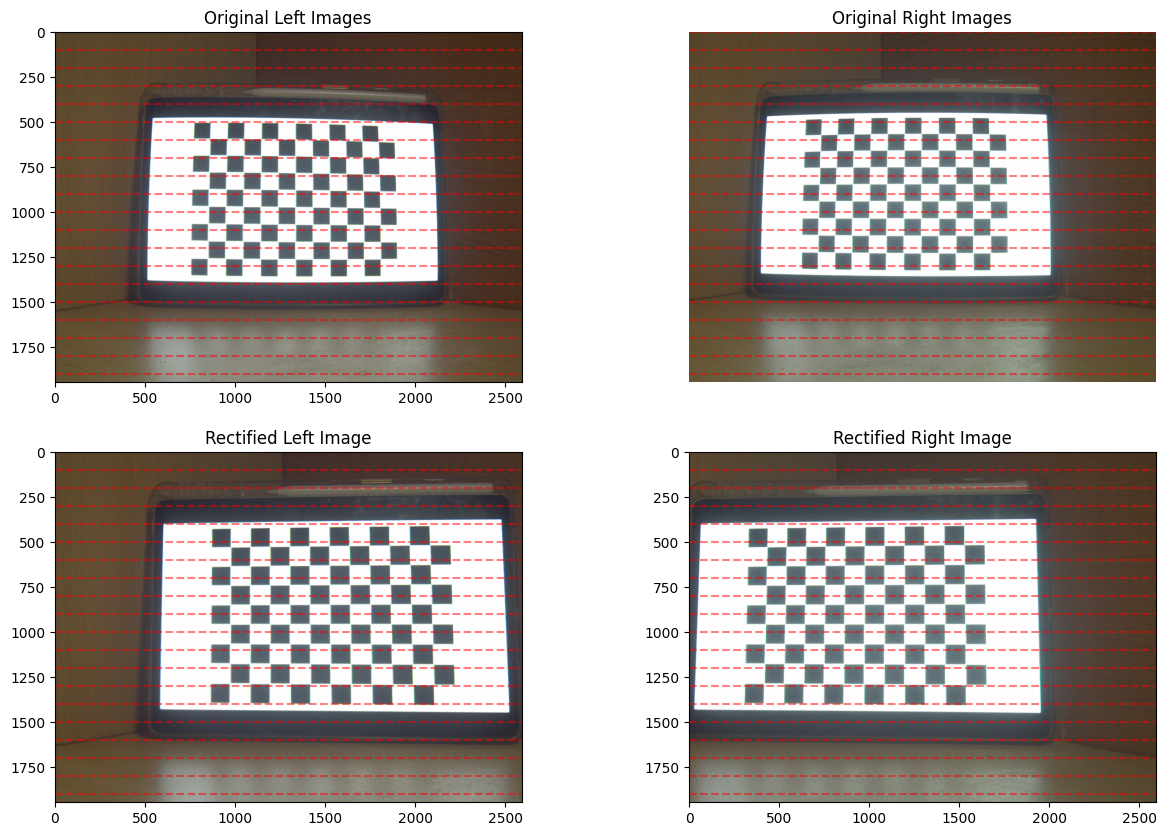

In [39]:
# 计算左右图像的畸变校正和立体校正映射表（用于快速 warp 图像）
left_map1, left_map2 = cv2.initUndistortRectifyMap(
    K1, D1, R1, P1, img_shape, cv2.CV_16SC2
)
right_map1, right_map2 = cv2.initUndistortRectifyMap(
    K2, D2, R2, P2, img_shape, cv2.CV_16SC2
)

# 测试校正效果（以第一对图像为例）
# 读取原始图像
img_l = cv2.imread(left_path[0])
img_r = cv2.imread(right_path[0])

# 应用校正映射
rectified_l = cv2.remap(img_l, left_map1, left_map2, cv2.INTER_LINEAR)
rectified_r = cv2.remap(img_r, right_map1, right_map2, cv2.INTER_LINEAR)

img_height = img_shape[1]
line_interval = 100
y_values = np.arange(0, img_height, line_interval)

# 可视化校正结果（绘制水平线验证极线对齐）
plt.figure(figsize=(15, 10))
# 左校正图
plt.subplot(221)
plt.imshow(cv2.cvtColor(img_l, cv2.COLOR_BGR2RGB))
for y in y_values:
    plt.axhline(y=y, color='r', linestyle='--', alpha=0.5)
plt.title('Original Left Images')

plt.subplot(222)
plt.imshow(cv2.cvtColor(img_r, cv2.COLOR_BGR2RGB))
for y in y_values:
    plt.axhline(y=y, color='r', linestyle='--', alpha=0.5)
plt.axis('off')
plt.title('Original Right Images')

plt.subplot(223)
plt.imshow(cv2.cvtColor(rectified_l, cv2.COLOR_BGR2RGB))
for y in y_values:
    plt.axhline(y=y, color='r', linestyle='--', alpha=0.5)
plt.title('Rectified Left Image')

plt.subplot(224)
plt.imshow(cv2.cvtColor(rectified_r, cv2.COLOR_BGR2RGB))
for y in y_values:
    plt.axhline(y=y, color='r', linestyle='--', alpha=0.5)
plt.title('Rectified Right Image')
plt.show()

In [40]:
# 将校正后的图像转换为灰度图（SGBM算法输入要求）
rectified_l_gray = cv2.cvtColor(rectified_l, cv2.COLOR_BGR2GRAY)
rectified_r_gray = cv2.cvtColor(rectified_r, cv2.COLOR_BGR2GRAY)

print(f"校正后图像尺寸: {rectified_l_gray.shape}")

校正后图像尺寸: (1944, 2592)


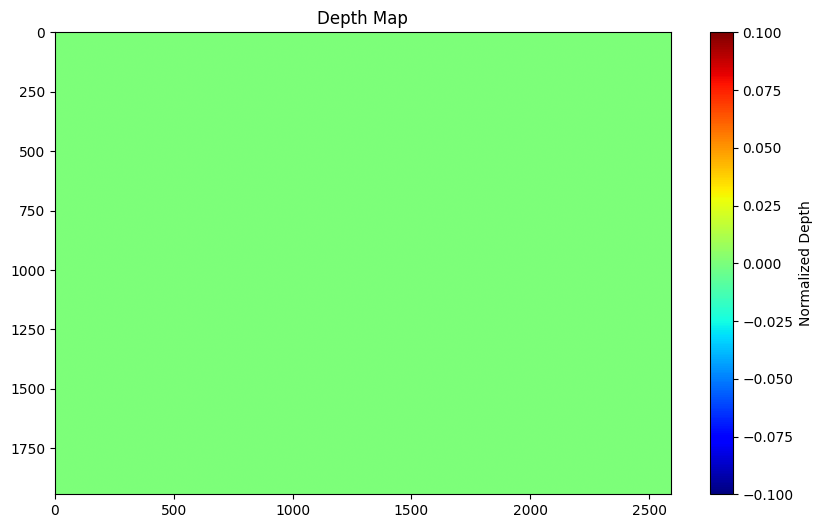

In [41]:
# 计算3D点云
points_3d = cv2.reprojectImageTo3D(disparity, Q, handleMissingValues=True)
depth_map = points_3d[..., 2]  # 提取z分量作为深度

# 可视化深度图
depth_map_norm = cv2.normalize(depth_map, None, 0, 255, cv2.NORM_MINMAX, cv2.CV_8U)
plt.figure(figsize=(10, 6))
plt.imshow(depth_map_norm, cmap='jet')
plt.colorbar(label='Normalized Depth')
plt.title('Depth Map')
plt.show()

In [42]:
def init_sgbm(num_disparities=128, block_size=5):
    """
    初始化SGBM立体匹配器
    num_disparities: 视差范围（必须是16的倍数）
    block_size: 匹配块大小（奇数，影响精度与噪声）
    """
    sgbm = cv2.StereoSGBM_create(
        minDisparity=0,               # 最小视差
        numDisparities=num_disparities,  # 视差范围（最大值-最小值）
        blockSize=block_size,         # 匹配块大小（奇数）
        P1=8 * 3 * block_size **2,    # 平滑项参数1（控制相邻像素视差变化）
        P2=32 * 3 * block_size **2,   # 平滑项参数2（P2>P1，值越大视差越平滑）
        disp12MaxDiff=1,              # 左右视差图最大允许差异
        preFilterCap=63,              # 预滤波截断值
        uniquenessRatio=10,           # 视差唯一性阈值（过滤歧义匹配）
        speckleWindowSize=100,        # 斑点滤波窗口大小
        speckleRange=32,              # 斑点滤波范围
        mode=cv2.STEREO_SGBM_MODE_SGBM_3WAY  # 优化模式（3WAY速度与精度平衡）
    )
    return sgbm

# 初始化SGBM（可根据需求调整num_disparities和block_size）
sgbm = init_sgbm(num_disparities=128, block_size=5)

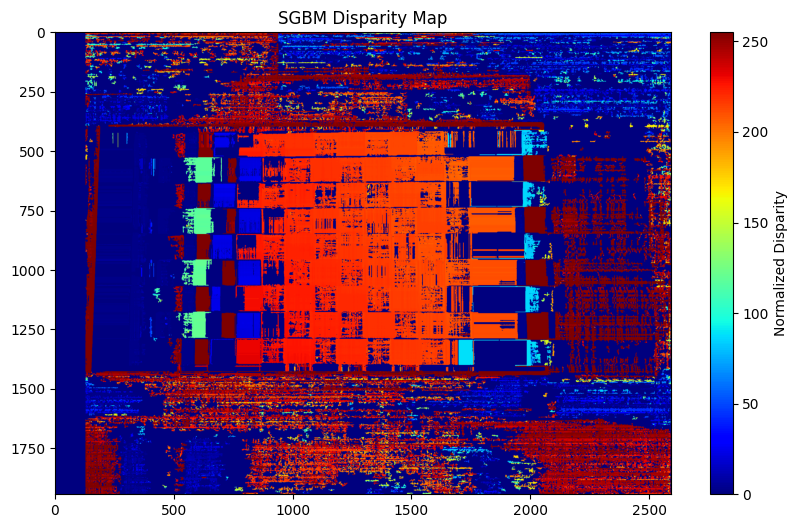

In [43]:
# 计算视差图
disparity = sgbm.compute(rectified_l_gray, rectified_r_gray)

# 视差图归一化（转换为0-255范围，便于可视化）
disparity_norm = cv2.normalize(
    disparity, None, 
    alpha=0, beta=255, 
    norm_type=cv2.NORM_MINMAX, 
    dtype=cv2.CV_8U
)

# 可视化视差图
plt.figure(figsize=(10, 6))
plt.imshow(disparity_norm, cmap='jet')
plt.colorbar(label='Normalized Disparity')
plt.title('SGBM Disparity Map')
plt.show()

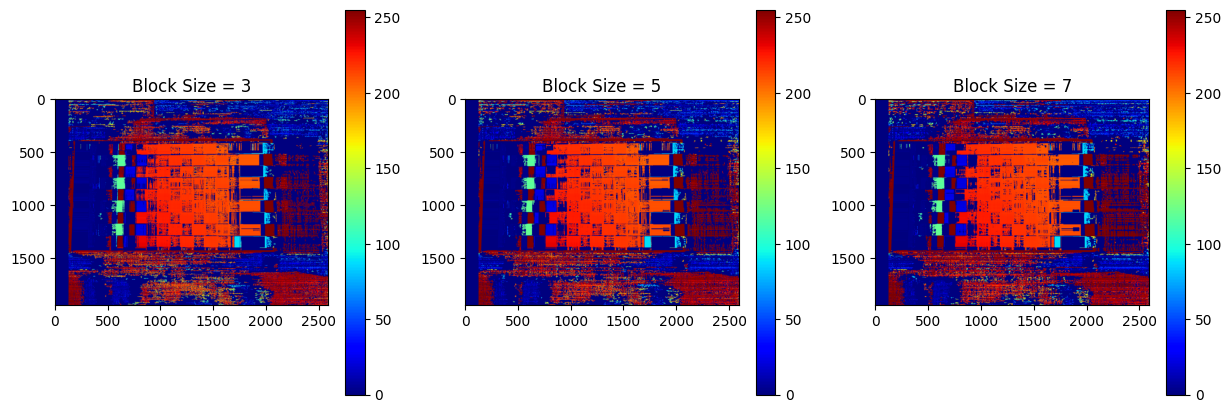

In [44]:
block_sizes = [3, 5, 7]  # 测试不同块大小
disparity_norm_list = []

for bs in block_sizes:
    sgbm = init_sgbm(block_size=bs)
    disp = sgbm.compute(rectified_l_gray, rectified_r_gray)
    disp_norm = cv2.normalize(disp, None, 0, 255, cv2.NORM_MINMAX, cv2.CV_8U)
    disparity_norm_list.append(disp_norm)

# 可视化不同块大小的视差图
plt.figure(figsize=(15, 5))
for i, bs in enumerate(block_sizes):
    plt.subplot(1, 3, i+1)
    plt.imshow(disparity_norm_list[i], cmap='jet')
    plt.colorbar()
    plt.title(f'Block Size = {bs}')
plt.show()

In [47]:
print(disparity)

[[ -16  -16  -16 ...  -16  -16  -16]
 [ -16  -16  -16 ...  -16  -16  704]
 [ -16  -16  -16 ...  357  361  704]
 ...
 [ -16  -16  -16 ... 1744 1744  -16]
 [ -16  -16  -16 ... 1745 1744  -16]
 [ -16  -16  -16 ... 1745 1745  -16]]


In [48]:
print(disparity_norm)

[[  0   0   0 ...   0   0   0]
 [  0   0   0 ...   0   0  90]
 [  0   0   0 ...  46  47  90]
 ...
 [  0   0   0 ... 219 219   0]
 [  0   0   0 ... 219 219   0]
 [  0   0   0 ... 219 219   0]]


In [54]:
# 将视差图转换为3D点云（x, y, z坐标）
points_3d = cv2.reprojectImageTo3D(
    disparity, Q, 
    handleMissingValues=True  # 忽略无效视差点
)

In [55]:
print(points_3d)

[[[ 3613.4375    4410.8184   10000.      ]
  [ 3608.9187    4410.8184   10000.      ]
  [ 3604.4       4410.8184   10000.      ]
  ...
  [-8085.7305    4410.8184   10000.      ]
  [-8090.2495    4410.8184   10000.      ]
  [-8094.768     4410.8184   10000.      ]]

 [[ 3613.4375    4406.3      10000.      ]
  [ 3608.9187    4406.3      10000.      ]
  [ 3604.4       4406.3      10000.      ]
  ...
  [-8085.7305    4406.3      10000.      ]
  [-8090.2495    4406.3      10000.      ]
  [  183.972     -100.14317    432.4264  ]]

 [[ 3613.4375    4401.781    10000.      ]
  [ 3608.9187    4401.781    10000.      ]
  [ 3604.4       4401.781    10000.      ]
  ...
  [  362.38568   -197.2787     852.74    ]
  [  358.57062   -195.09279    843.2913  ]
  [  183.972     -100.040474   432.4264  ]]

 ...

 [[ 3613.4375   -4360.1685   10000.      ]
  [ 3608.9187   -4360.1685   10000.      ]
  [ 3604.4      -4360.1685   10000.      ]
  ...
  [   74.181015    40.001545   174.55743 ]
  [   74.22247    

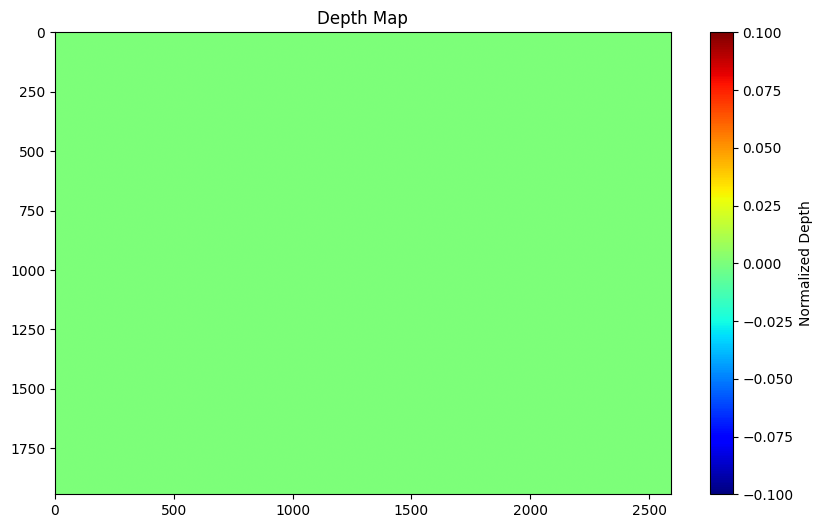

有效3D点数量: 2474261
示例3D点坐标: 
[[-24.83913  -36.09877  155.71774 ]
 [-24.244099 -35.28655  152.21408 ]
 [-24.220058 -35.3042   152.29024 ]]


In [ ]:
# 过滤无效点（z≤0的点为无效深度）
valid_mask = disparity > disparity.min()
points_3d_valid = points_3d[valid_mask]  # 有效3D点坐标

# 获取对应点的颜色（从左图提取，与3D点对齐）
colors = cv2.cvtColor(rectified_l, cv2.COLOR_BGR2RGB)
colors_valid = colors[valid_mask]  # 有效点的颜色

# 可视化深度图（提取z分量）
depth_map = points_3d[..., 2]  # 深度图为3D点的z分量
depth_map_norm = cv2.normalize(
    depth_map, None, 
    alpha=0, beta=255, 
    norm_type=cv2.NORM_MINMAX, 
    dtype=cv2.CV_8U
)

plt.figure(figsize=(10, 6))
plt.imshow(depth_map_norm, cmap='jet')
plt.colorbar(label='Normalized Depth')
plt.title('Depth Map')
plt.show()

print(f"有效3D点数量: {len(points_3d_valid)}")
print(f"示例3D点坐标: \n{points_3d_valid[:3]}")

In [56]:
print(depth_map)

[[-19026.762   -19026.762   -19026.762   ... -19026.762   -19026.762
  -19026.762  ]
 [-19026.762   -19026.762   -19026.762   ... -19026.762   -19026.762
     432.4264 ]
 [-19026.762   -19026.762   -19026.762   ...    852.74       843.2913
     432.4264 ]
 ...
 [-19026.762   -19026.762   -19026.762   ...    174.55743    174.55743
  -19026.762  ]
 [-19026.762   -19026.762   -19026.762   ...    174.45741    174.55743
  -19026.762  ]
 [-19026.762   -19026.762   -19026.762   ...    174.45741    174.45741
  -19026.762  ]]


In [57]:
print(depth_map_norm)

[[0 0 0 ... 0 0 0]
 [0 0 0 ... 0 0 0]
 [0 0 0 ... 0 0 0]
 ...
 [0 0 0 ... 0 0 0]
 [0 0 0 ... 0 0 0]
 [0 0 0 ... 0 0 0]]


In [58]:
# 先验证有效点和颜色的数量是否一致
print(f"有效3D点数量: {len(points_3d_valid)}")
print(f"有效颜色数量: {len(colors_valid)}")

# 若数量不一致，说明掩码应用错误，需重新过滤
if len(points_3d_valid) != len(colors_valid):
    print("警告：点云坐标和颜色数量不一致！请检查掩码应用逻辑。")
    # 强制截断为较短的长度（确保后续不报错）
    min_len = min(len(points_3d_valid), len(colors_valid))
    points_3d_valid = points_3d_valid[:min_len]
    colors_valid = colors_valid[:min_len]

有效3D点数量: 2474261
有效颜色数量: 2474261


In [59]:
def write_ply(points, colors, K, R, T, output_path):
    """
    写入带颜色的3D点云和相机姿态到PLY文件（名称唯一版）
    points: 3D点坐标 (N, 3)
    colors: 对应颜色 (N, 3)，范围0-255
    K, R, T: 相机内参、旋转矩阵、平移向量
    """
    # 确保点和颜色数量一致
    min_len = min(len(points), len(colors))
    points = points[:min_len]
    colors = colors[:min_len]
    
    # 定义点云的PLY类型（名称为"vertex"）
    point_dtype = [
        ('x', 'f4'), ('y', 'f4'), ('z', 'f4'),
        ('red', 'u1'), ('green', 'u1'), ('blue', 'u1')
    ]
    points_with_color = np.empty(min_len, dtype=point_dtype)
    points_with_color['x'] = points[:, 0]
    points_with_color['y'] = points[:, 1]
    points_with_color['z'] = points[:, 2]
    points_with_color['red'] = colors[:, 0]
    points_with_color['green'] = colors[:, 1]
    points_with_color['blue'] = colors[:, 2]
    ply_points = PlyElement.describe(points_with_color, 'vertex')

    # 定义相机的PLY类型（名称为"camera"，避免与点云重复）
    camera_dtype = [
        ('x', 'f4'), ('y', 'f4'), ('z', 'f4'),
        ('red', 'u1'), ('green', 'u1'), ('blue', 'u1')
    ]
    left_cam = np.array([(0, 0, 0, 255, 0, 0)], dtype=camera_dtype)  # 左相机（红色）
    right_cam_pos = -R.T @ T.flatten()
    right_cam = np.array([(right_cam_pos[0], right_cam_pos[1], right_cam_pos[2], 0, 0, 255)], dtype=camera_dtype)  # 右相机（蓝色）
    ply_cams = PlyElement.describe(np.hstack([left_cam, right_cam]), 'camera')  # 名称改为"camera"

    # 写入PLY文件（点云和相机名称唯一）
    PlyData([ply_points, ply_cams]).write(output_path)
    print(f"PLY文件已保存至: {output_path}")

# 生成PLY文件
write_ply(
    points_3d_valid, 
    colors_valid, 
    K1, R, T, 
    "sgbm_point_cloud_final.ply"
)

PLY文件已保存至: sgbm_point_cloud_final.ply


In [60]:
# 左相机内参 K1 = [[fx, 0, cx], [0, fy, cy], [0, 0, 1]]
fx = K1[0, 0]
fy = K1[1, 1]
cx = K1[0, 2]
cy = K1[1, 2]

# 右相机主点 cx'（从右相机内参 K2 提取）
cx_prime = K2[0, 2]

# 平移向量 T 的x分量（基线相关参数）
Tx = T[0]  

In [61]:
# 视差图和颜色图的尺寸
height, width = disparity.shape
rectified_l_rgb = cv2.cvtColor(rectified_l, cv2.COLOR_BGR2RGB)  # 左图颜色（用于点云着色）

# 存储手动计算的3D点和颜色
points_3d_manual = []
colors_3d_manual = []

for y in range(height):
    for x in range(width):
        d = disparity[y, x]  # 当前像素的视差
        if d <= 0:  # 跳过无效视差（视差<=0无意义）
            continue
        
        # 计算深度 Z
        denominator = d - (cx - cx_prime)
        if denominator == 0:
            continue  # 避免除以0
        Z = (fx * Tx) / denominator  # 深度公式
        
        # 计算X、Y坐标
        X = (x - cx) * Z / fx
        Y = (y - cy) * Z / fy
        
        # 存储3D点和对应颜色
        points_3d_manual.append([X, Y, Z])
        colors_3d_manual.append(rectified_l_rgb[y, x].tolist())

# 转换为numpy数组（便于后续处理）
points_3d_manual = np.array(points_3d_manual, dtype=np.float32)
colors_3d_manual = np.array(colors_3d_manual, dtype=np.uint8)

print(f"手动计算的有效3D点数量: {len(points_3d_manual)}")

手动计算的有效3D点数量: 2318276


In [62]:
from plyfile import PlyData, PlyElement

def write_manual_ply(points, colors, output_path):
    """将手动计算的3D点云写入PLY文件"""
    # 定义PLY数据类型：(x,y,z, red, green, blue)
    dtype = [
        ('x', 'f4'), ('y', 'f4'), ('z', 'f4'),
        ('red', 'u1'), ('green', 'u1'), ('blue', 'u1')
    ]
    
    # 构造结构化数组
    points_with_color = np.empty(len(points), dtype=dtype)
    points_with_color['x'] = points[:, 0]
    points_with_color['y'] = points[:, 1]
    points_with_color['z'] = points[:, 2]
    points_with_color['red'] = colors[:, 0]
    points_with_color['green'] = colors[:, 1]
    points_with_color['blue'] = colors[:, 2]
    
    # 生成PLY元素并写入文件
    ply_element = PlyElement.describe(points_with_color, 'vertex')
    PlyData([ply_element]).write(output_path)
    print(f"手动计算的点云已保存至: {output_path}")

# 调用函数生成PLY文件
write_manual_ply(points_3d_manual, colors_3d_manual, "manual_stereo_point_cloud.ply")

ValueError: could not broadcast input array from shape (2318276,1) into shape (2318276,)

In [63]:
# 先检查points_3d_manual的形状（应为 (N, 3)）
print("points_3d_manual 原始形状:", points_3d_manual.shape)

# 若存在多余维度，通过reshape或squeeze去除
points_3d_manual = np.squeeze(points_3d_manual)  # 去除尺寸为1的维度
print("处理后的形状:", points_3d_manual.shape)  # 确保输出为 (N, 3)

# 重新定义写入函数，确保赋值时是一维数组
def write_manual_ply(points, colors, output_path):
    dtype = [
        ('x', 'f4'), ('y', 'f4'), ('z', 'f4'),
        ('red', 'u1'), ('green', 'u1'), ('blue', 'u1')
    ]
    
    points_with_color = np.empty(len(points), dtype=dtype)
    # 使用.ravel()将切片结果转换为一维数组
    points_with_color['x'] = points[:, 0].ravel()
    points_with_color['y'] = points[:, 1].ravel()
    points_with_color['z'] = points[:, 2].ravel()
    points_with_color['red'] = colors[:, 0].ravel()
    points_with_color['green'] = colors[:, 1].ravel()
    points_with_color['blue'] = colors[:, 2].ravel()
    
    ply_element = PlyElement.describe(points_with_color, 'vertex')
    PlyData([ply_element]).write(output_path)
    print(f"手动计算的点云已保存至: {output_path}")

# 调用函数
write_manual_ply(points_3d_manual, colors_3d_manual, "manual_stereo_point_cloud.ply")

points_3d_manual 原始形状: (2318276, 3, 1)
处理后的形状: (2318276, 3)
手动计算的点云已保存至: manual_stereo_point_cloud.ply
